In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!nvidia-smi

Sat Jul 11 12:01:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [4]:
import zipfile
import os

# ZIP dosyasının yolu
zip_path = "/content/drive/MyDrive/combined_dataset_for_yolov8_versiyon2.zip"

# Çıkarılacak klasör
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset çıkarıldı.")

Dataset çıkarıldı.


In [5]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 51.9/112.6 GB disk)


In [6]:
from ultralytics import YOLO

from IPython.display import display, Image

In [8]:
!pip uninstall -y numpy pandas
!pip install -q numpy==1.26.4 pandas==2.2.2 ultralytics --upgrade

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incomp

In [13]:
import os

# Labels klasörünün yolu
labels_dir = "/content/dataset/combined_dataset_for_yolov8_versiyon2/valid/labels"   # Kendi yoluna göre değiştir

for root, dirs, files in os.walk(labels_dir):
    for file in files:
        if file.lower().startswith("fire") and file.endswith(".txt"):
            file_path = os.path.join(root, file)

            with open(file_path, "r") as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:  # YOLO formatı: class x y w h
                    parts[0] = "3"
                    new_lines.append(" ".join(parts) + "\n")
                else:
                    new_lines.append(line)

            with open(file_path, "w") as f:
                f.writelines(new_lines)

            print(f"Güncellendi: {file_path}")

print("İşlem tamamlandı.")

İşlem tamamlandı.


In [10]:
from ultralytics import YOLO

# Fix: The previous attempt to upgrade numpy and ultralytics did not fully
# upgrade ultralytics itself, as indicated by the 'New ultralytics/8.4.92 available'
# message and the reported version 'YOLOv8.2.103'. This likely prevented the
# numpy compatibility issue from being fully resolved.
# This revised fix will ensure ultralytics is updated to its latest version first,
# and then explicitly install numpy==2.0.0 to ensure compatibility.
!pip install --upgrade ultralytics -q
!pip install --upgrade numpy==2.0.0 -q

# Clear the output to keep the notebook clean
from IPython import display
display.clear_output()

model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/combined_dataset_for_yolov8_versiyon2/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

New https://pypi.org/project/ultralytics/8.4.92 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/dataset/combined_dataset_for_yolov8_versiyon2/data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_mas

ImportError: cannot import name 'GIT' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

/content


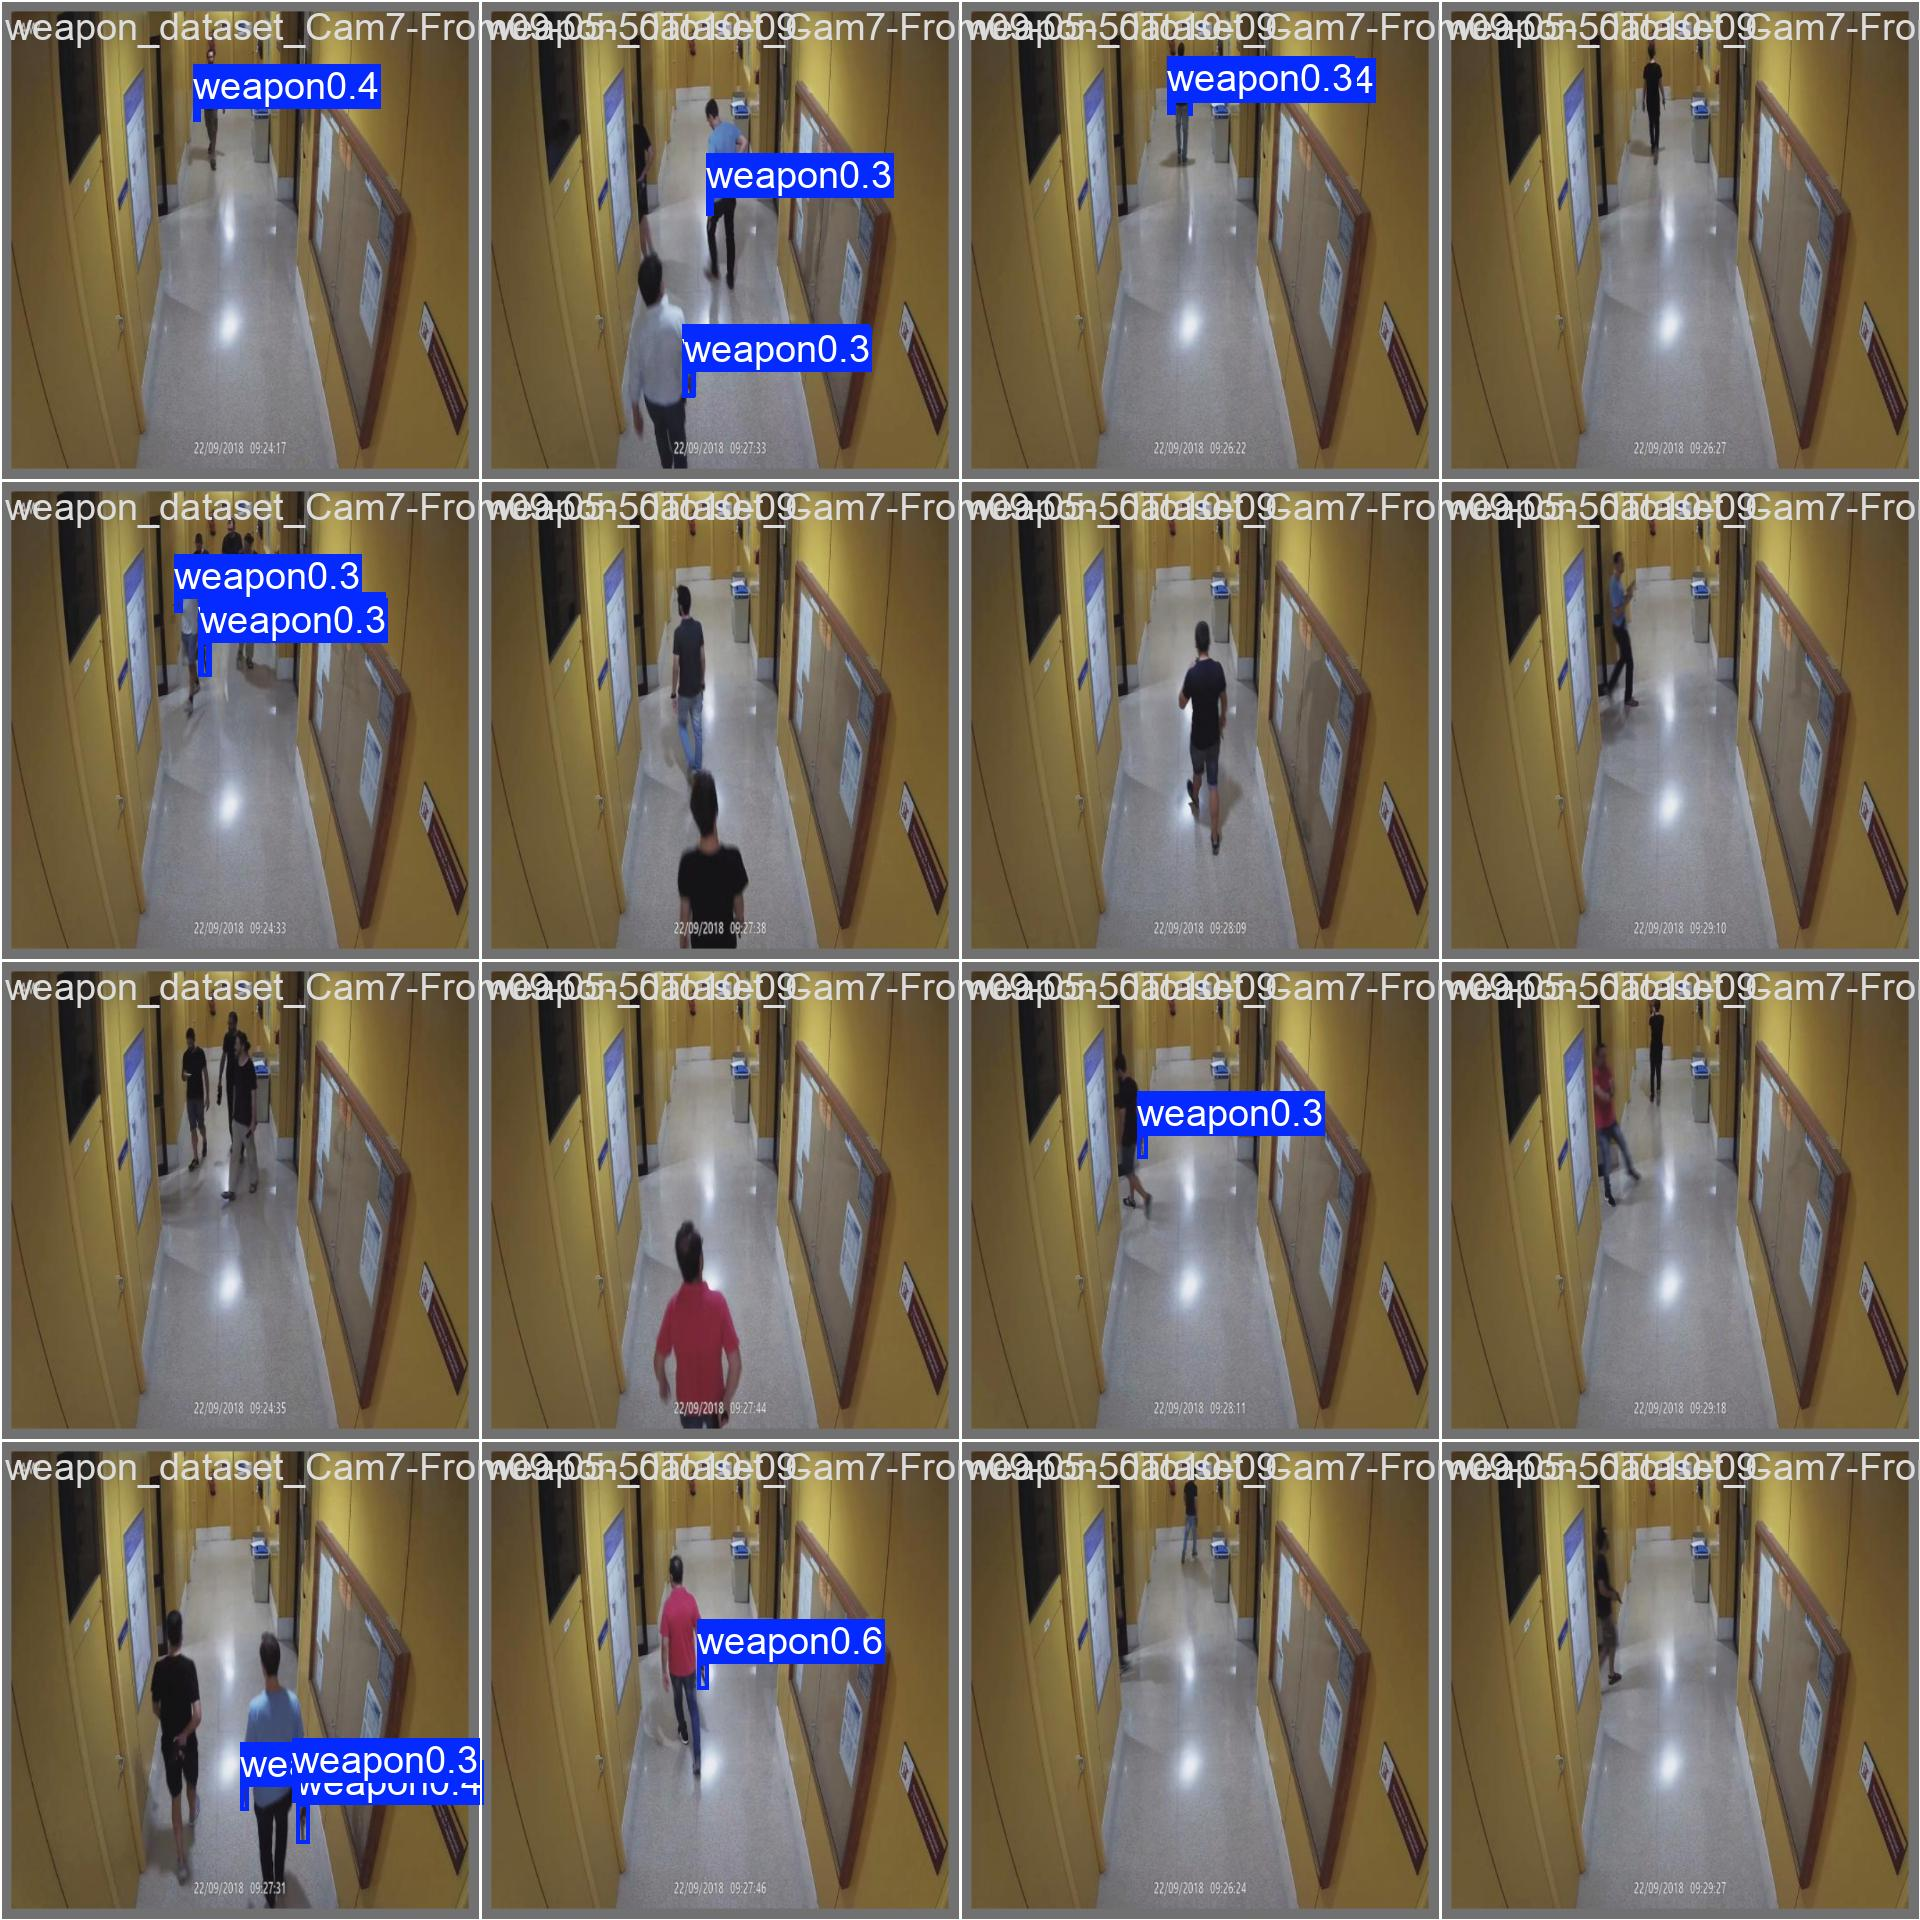

In [24]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train-5/val_batch0_pred.jpg', width=600)

In [27]:
%cd {HOME}

!yolo task=detect mode=val model=/content/runs/detect/train-5/weights/best.pt data=/content/dataset/combined_dataset_for_yolov8/data.yaml

/content
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 859.5±257.0 MB/s, size: 28.6 KB)
val: Scanning /content/dataset/combined_dataset_for_yolov8/valid/labels.cache... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 5.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.2it/s 1.4s
                   all         48         58      0.872      0.517      0.689      0.384
                weapon         48         58      0.872      0.517      0.689      0.384
Speed: 6.3ms preprocess, 5.4ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to /content/runs/detect/val-2
💡 Learn more at https://docs.ultralytics.com/modes/val
